# Etapa 2 - Limpieza, transformación y análisis exploratorio de datos

## Proyecto Más Visión

En esta etapa se realiza la carga, exploración, limpieza y transformación de los datos históricos de ventas de Más Visión.  
Además, se incorpora una tabla de descuentos mensuales por tipo de producto y se desarrolla un análisis exploratorio de datos para identificar tendencias, patrones, estacionalidades y posibles valores atípicos.

*Objetivo:* preparar un dataset limpio y enriquecido para su uso en los siguientes módulos del proyecto.

In [1]:
# Importación de librerías principales

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración visual básica
pd.set_option('display.max_columns', None)

# Formato bonito para números
pd.options.display.float_format = '{:,.2f}'.format

In [2]:
from google.colab import files

uploaded = files.upload()

Saving Etapa 1 - Data ventas Mas Vision - Ali Vega.xlsx to Etapa 1 - Data ventas Mas Vision - Ali Vega.xlsx


In [3]:
df = pd.read_excel('Etapa 1 - Data ventas Mas Vision - Ali Vega.xlsx')

## 1. Carga y exploración inicial de los datos

En esta sección se revisa la estructura general del dataset, las primeras filas, el tipo de datos de cada columna y las estadísticas descriptivas iniciales.

In [4]:
# Visualizar primeras filas
df.head()

,id_suc,Cluster\n(Punto de venta),Año,Mes,Venta
0,1,E,2019,enero,20.03
1,1,E,2019,febrero,20.02
2,1,E,2019,marzo,20.25
3,1,E,2019,abril,20.11
4,1,E,2019,mayo,19.86


In [5]:
# Información general del dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26580 entries, 0 to 26579
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   id_suc                    26580 non-null  int64  
 1   Cluster
(Punto de venta)  26580 non-null  object 
 2   Año                       26580 non-null  int64  
 3   Mes                       26580 non-null  object 
 4   Venta                     26580 non-null  float64
dtypes: float64(1), int64(2), object(2)
memory usage: 1.0+ MB


In [6]:
# Estadísticas descriptivas
df.describe()

,id_suc,Año,Venta
count,"26,580.00","26,580.00","26,580.00"
mean,222.00,"2,021.80",17.20
std,127.89,1.72,5.58
min,1.00,"2,019.00",0.00
25%,111.00,"2,021.00",18.46
50%,222.00,"2,022.00",18.90
75%,333.00,"2,023.00",19.33
max,443.00,"2,024.00",21.62


In [7]:
# Revisión de columnas disponibles
df.columns

Index(['id_suc', 'Cluster\n(Punto de venta)', 'Año', 'Mes', 'Venta'], dtype='object')

## 2. Limpieza de datos

Se revisan valores nulos, registros duplicados y tipos de datos.  
El objetivo es asegurar que el dataset tenga una estructura consistente antes del análisis.

In [8]:
# Revisión de valores nulos por columna
df.isnull().sum()

,0
id_suc,0
Cluster\n(Punto de venta),0
Año,0
Mes,0
Venta,0


In [9]:
# Revisión de registros duplicados
df.duplicated().sum()

np.int64(0)

In [10]:
# Eliminación de duplicados, si existen
df = df.drop_duplicates()

# Confirmación
df.duplicated().sum()

np.int64(0)

In [11]:
# Revisión de tipos de datos
df.dtypes

,0
id_suc,int64
Cluster\n(Punto de venta),object
Año,int64
Mes,object
Venta,float64


In [12]:
# Limpiar nombres de columnas

df.columns = df.columns.str.strip()
df.columns = df.columns.str.replace('\n',' ', regex=True)

df.columns

Index(['id_suc', 'Cluster (Punto de venta)', 'Año', 'Mes', 'Venta'], dtype='object')

In [13]:
# Asegurar tipos de datos correctos

df['Venta'] = df['Venta'].astype(float)
df['Mes'] = df['Mes'].str.lower().str.strip()

df.dtypes

,0
id_suc,int64
Cluster (Punto de venta),object
Año,int64
Mes,object
Venta,float64


## 3. Incorporación de tabla de descuentos

Se crea una tabla auxiliar con descuentos mensuales por tipo de producto.  
Posteriormente, esta tabla se integra al dataset principal mediante la columna de mes.

In [14]:
# Creación de tabla de descuentos mensuales por tipo de producto

descuentos = pd.DataFrame({
    'Mes': ['enero', 'febrero', 'marzo', 'abril', 'mayo', 'junio',
            'julio', 'agosto', 'septiembre', 'octubre', 'noviembre', 'diciembre'],
    'Descuento_Oftalmico': [0.10, 0.12, 0.08, 0.15, 0.10, 0.05,
                            0.07, 0.09, 0.11, 0.13, 0.15, 0.18],
    'Descuento_Solar': [0.05, 0.07, 0.10, 0.12, 0.15, 0.18,
                        0.20, 0.17, 0.12, 0.10, 0.08, 0.06],
    'Descuento_Contacto': [0.08, 0.09, 0.07, 0.10, 0.11, 0.12,
                           0.13, 0.10, 0.09, 0.08, 0.11, 0.14]
})

descuentos

,Mes,Descuento_Oftalmico,Descuento_Solar,Descuento_Contacto
0,enero,0.10,0.05,0.08
1,febrero,0.12,0.07,0.09
2,marzo,0.08,0.10,0.07
3,abril,0.15,0.12,0.10
4,mayo,0.10,0.15,0.11
5,junio,0.05,0.18,0.12
6,julio,0.07,0.20,0.13
7,agosto,0.09,0.17,0.10
8,septiembre,0.11,0.12,0.09
9,octubre,0.13,0.10,0.08


In [15]:
# Unión del dataset principal con la tabla de descuentos

df = df.merge(descuentos, on='Mes', how='left')

df.head()

,id_suc,Cluster (Punto de venta),Año,Mes,Venta,Descuento_Oftalmico,Descuento_Solar,Descuento_Contacto
0,1,E,2019,enero,20.03,0.10,0.05,0.08
1,1,E,2019,febrero,20.02,0.12,0.07,0.09
2,1,E,2019,marzo,20.25,0.08,0.10,0.07
3,1,E,2019,abril,20.11,0.15,0.12,0.10
4,1,E,2019,mayo,19.86,0.10,0.15,0.11


In [16]:
# Verificar si la unión generó valores nulos en los descuentos

df[['Descuento_Oftalmico', 'Descuento_Solar', 'Descuento_Contacto']].isnull().sum()

,0
Descuento_Oftalmico,0
Descuento_Solar,0
Descuento_Contacto,0


## 4. Transformaciones de variables

En esta sección se convierte el mes de texto a número y se crea una columna fecha combinando año y mes.

Estas transformaciones permiten realizar análisis temporales más claros y facilitan la detección de patrones de comportamiento en las ventas.

In [17]:
# Diccionario para convertir meses de texto a número

meses = {
    'enero':1,
    'febrero':2,
    'marzo':3,
    'abril':4,
    'mayo':5,
    'junio':6,
    'julio':7,
    'agosto':8,
    'septiembre':9,
    'octubre':10,
    'noviembre':11,
    'diciembre':12
}

df['Mes_Num'] = df['Mes'].map(meses)

df[['Mes','Mes_Num']].head()

,Mes,Mes_Num
0,enero,1
1,febrero,2
2,marzo,3
3,abril,4
4,mayo,5


In [18]:
# Creación de columna fecha

df['Fecha'] = pd.to_datetime(
    dict(
        year=df['Año'],
        month=df['Mes_Num'],
        day=1
    )
)

df[['Año','Mes','Mes_Num','Fecha']].head()

,Año,Mes,Mes_Num,Fecha
0,2019,enero,1,2019-01-01
1,2019,febrero,2,2019-02-01
2,2019,marzo,3,2019-03-01
3,2019,abril,4,2019-04-01
4,2019,mayo,5,2019-05-01


## 5. Análisis exploratorio de datos (EDA)

En esta sección se realizan análisis descriptivos, agrupaciones, visualizaciones, detección de outliers y análisis de correlaciones.

El objetivo es identificar tendencias, estacionalidades, diferencias entre puntos de venta y posibles relaciones entre variables.

In [19]:
# Estadísticas descriptivas generales
df.describe()

,id_suc,Año,Venta,Descuento_Oftalmico,Descuento_Solar,Descuento_Contacto,Mes_Num,Fecha
count,"26,580.00","26,580.00","26,580.00","26,580.00","26,580.00","26,580.00","26,580.00",26580
mean,222.00,"2,021.80",17.20,0.11,0.12,0.10,6.50,2022-04-04 11:11:59.999999744
min,1.00,"2,019.00",0.00,0.05,0.05,0.07,1.00,2019-01-01 00:00:00
25%,111.00,"2,021.00",18.46,0.09,0.08,0.09,3.75,2021-03-24 06:00:00
50%,222.00,"2,022.00",18.90,0.11,0.11,0.10,6.50,2022-06-16 00:00:00
75%,333.00,"2,023.00",19.33,0.14,0.15,0.11,9.25,2023-09-08 12:00:00
max,443.00,"2,024.00",21.62,0.18,0.20,0.14,12.00,2024-12-01 00:00:00
std,127.89,1.72,5.58,0.04,0.05,0.02,3.45,NaN


In [20]:
# Estadísticas descriptivas por punto de venta

df.groupby(
    'Cluster (Punto de venta)'
)['Venta'].describe()

,count,mean,std,min,25%,50%,75%,max
Cluster (Punto de venta),,,,,,,,
A,"3,000.00",17.45,4.30,0.00,18.16,18.44,18.73,19.94
B,120.00,14.61,8.32,0.00,14.48,18.64,20.76,21.62
C,"4,140.00",16.53,7.06,0.00,18.97,19.43,19.80,21.05
D,"5,220.00",18.68,2.07,0.00,18.58,18.88,19.19,20.62
E,"7,680.00",18.60,3.42,0.00,18.85,19.17,19.53,20.90
F,"6,360.00",14.69,7.66,0.00,17.91,18.55,18.88,20.23
G,60.00,15.51,6.68,0.00,16.26,18.29,19.04,20.39


## 6. Tendencias y patrones de ventas por año

En esta sección se agrupan las ventas por año para identificar cambios en el comportamiento comercial de la empresa a lo largo del tiempo.

El análisis anual permite detectar tendencias generales de crecimiento, disminución o estabilidad en las ventas históricas.

In [21]:
# Ventas totales por año

ventas_anuales = df.groupby(
    'Año'
)['Venta'].sum().reset_index()

ventas_anuales

,Año,Venta
0,2019,"85,084.31"
1,2021,"89,549.47"
2,2022,"91,063.51"
3,2023,"93,601.73"
4,2024,"97,907.06"


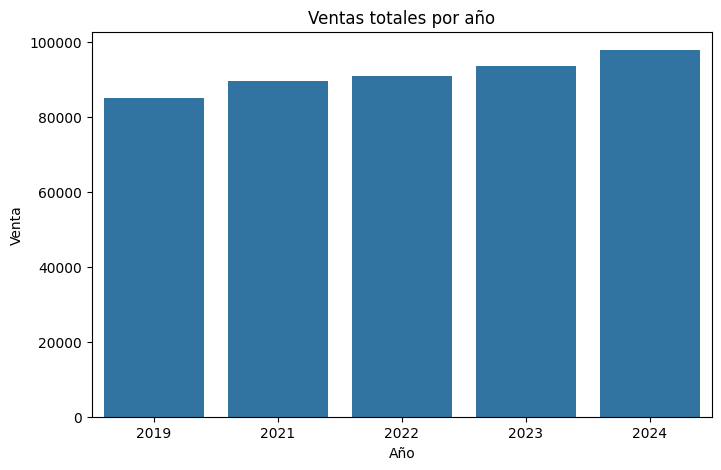

In [22]:
# Gráfico de ventas por año

plt.figure(figsize=(8,5))

sns.barplot(
    data=ventas_anuales,
    x='Año',
    y='Venta'
)

plt.title('Ventas totales por año')

plt.show()

## 7. Estacionalidad y comportamiento mensual

Se analizan las ventas por mes para identificar posibles patrones de estacionalidad.

Este análisis permite observar si existen meses con mayores o menores niveles de venta y evaluar comportamientos recurrentes dentro del año.

In [23]:
# Ventas por mes

ventas_mes = df.groupby(
    'Mes_Num'
)['Venta'].sum().reset_index()

ventas_mes

,Mes_Num,Venta
0,1,"37,800.79"
1,2,"37,567.44"
2,3,"37,784.23"
3,4,"37,708.13"
4,5,"37,944.29"
5,6,"37,832.11"
6,7,"38,020.15"
7,8,"38,128.91"
8,9,"37,989.59"
9,10,"38,269.36"


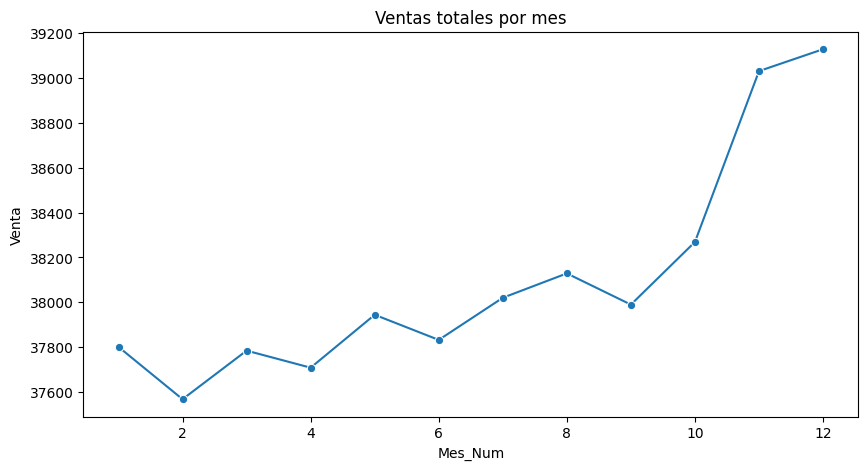

In [24]:
# Gráfico de ventas por mes

plt.figure(figsize=(10,5))

sns.lineplot(
    data=ventas_mes,
    x='Mes_Num',
    y='Venta',
    marker='o'
)

plt.title('Ventas totales por mes')

plt.show()

## 8. Ventas por punto de venta

En esta sección se agrupan las ventas por punto de venta para comparar el desempeño entre diferentes tipos de sucursal.

Esto permite identificar diferencias de comportamiento entre clusters comerciales.

In [25]:
# Ventas por punto de venta

ventas_cluster = df.groupby(
    'Cluster (Punto de venta)'
)['Venta'].sum().reset_index()

ventas_cluster

,Cluster (Punto de venta),Venta
0,A,"52,342.53"
1,B,"1,753.21"
2,C,"68,417.62"
3,D,"97,484.42"
4,E,"142,839.39"
5,F,"93,438.42"
6,G,930.49


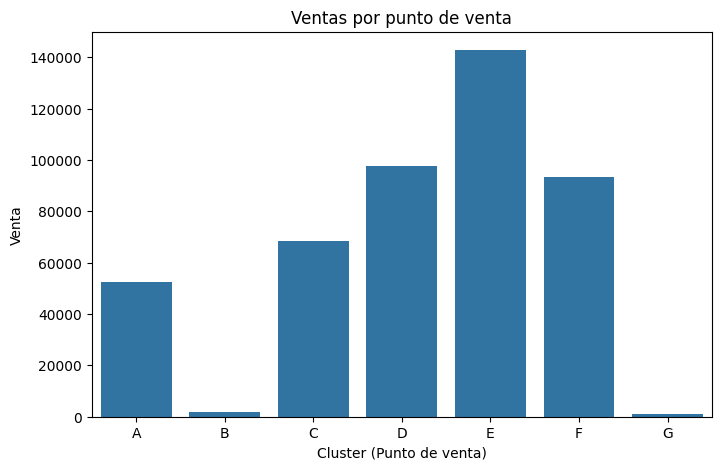

In [26]:
# Gráfico por punto de venta

plt.figure(figsize=(8,5))

sns.barplot(
    data=ventas_cluster,
    x='Cluster (Punto de venta)',
    y='Venta'
)

plt.title('Ventas por punto de venta')

plt.show()

## 9. Detección de outliers

Se analizan ventas individuales y ventas acumuladas por sucursal para identificar posibles valores atípicos.

Los outliers pueden representar sucursales con desempeño inusualmente alto o bajo.

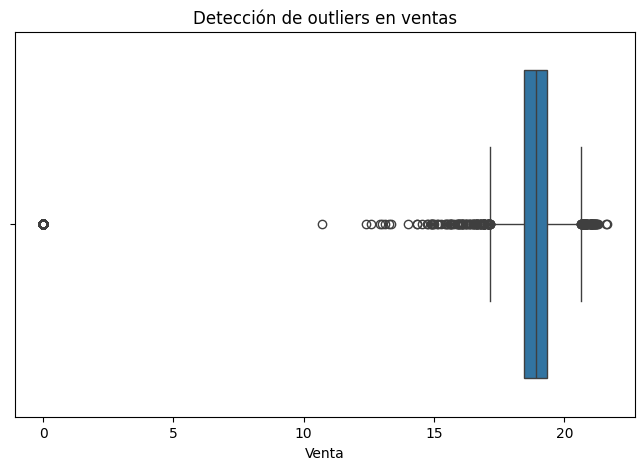

In [27]:
# Boxplot de ventas individuales

plt.figure(figsize=(8,5))

sns.boxplot(
    x=df['Venta']
)

plt.title('Detección de outliers en ventas')

plt.show()

### Interpretación de outliers

El boxplot permitió identificar posibles valores atípicos dentro de la distribución de ventas.

Estos registros podrían corresponder a periodos con comportamientos extraordinarios, promociones relevantes o diferencias operativas entre sucursales y formatos de tienda.

In [28]:
# Ventas acumuladas por sucursal

ventas_sucursal = df.groupby(
    'id_suc'
)['Venta'].sum().reset_index()

ventas_sucursal.sort_values(
    by='Venta',
    ascending=False
).head(10)

,id_suc,Venta
75,76,"1,236.53"
14,15,"1,225.07"
2,3,"1,224.06"
36,37,"1,217.46"
0,1,"1,210.62"
70,71,"1,205.86"
21,22,"1,203.15"
51,52,"1,202.99"
166,167,"1,202.59"
80,81,"1,201.52"


In [29]:
# Sucursales con menores ventas

ventas_sucursal.sort_values(
    by='Venta',
    ascending=True
).head(10)

,id_suc,Venta
303,304,16.66
312,313,18.81
307,308,31.14
304,305,33.55
306,307,34.71
311,312,36.13
309,310,38.17
310,311,38.82
302,303,52.03
305,306,52.75


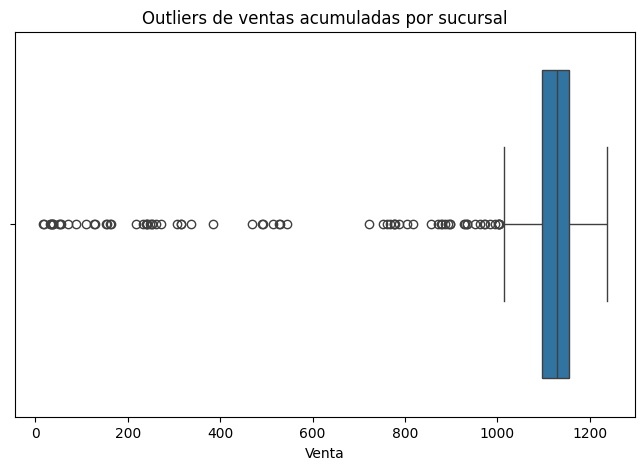

In [30]:
# Boxplot de ventas acumuladas por sucursal

plt.figure(figsize=(8,5))

sns.boxplot(
    x=ventas_sucursal['Venta']
)

plt.title(
    'Outliers de ventas acumuladas por sucursal'
)

plt.show()

## 10. Correlaciones entre variables

Se exploran relaciones entre variables numéricas mediante una matriz de correlación y gráficos de dispersión.

Este análisis ayuda a identificar posibles asociaciones entre ventas, descuentos y otras variables cuantitativas.

In [31]:
# Matriz de correlación

corr = df.select_dtypes(
    include='number'
).corr()

corr

,id_suc,Año,Venta,Descuento_Oftalmico,Descuento_Solar,Descuento_Contacto,Mes_Num
id_suc,1.00,-0.00,-0.21,-0.00,-0.00,0.00,-0.00
Año,-0.00,1.00,0.14,-0.00,0.00,-0.00,-0.00
Venta,-0.21,0.14,1.00,0.02,-0.01,0.02,0.03
Descuento_Oftalmico,-0.00,-0.00,0.02,1.00,-0.67,0.15,0.44
Descuento_Solar,-0.00,0.00,-0.01,-0.67,1.00,0.35,0.07
Descuento_Contacto,0.00,-0.00,0.02,0.15,0.35,1.00,0.50
Mes_Num,-0.00,-0.00,0.03,0.44,0.07,0.50,1.00


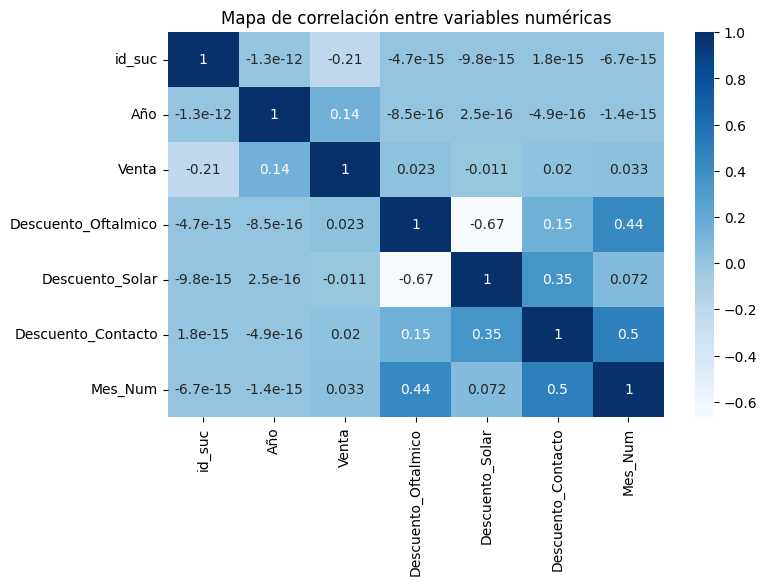

In [32]:
plt.figure(figsize=(8,5))

sns.heatmap(
    corr,
    annot=True,
    cmap='Blues'
)

plt.title('Mapa de correlación entre variables numéricas')

plt.show()

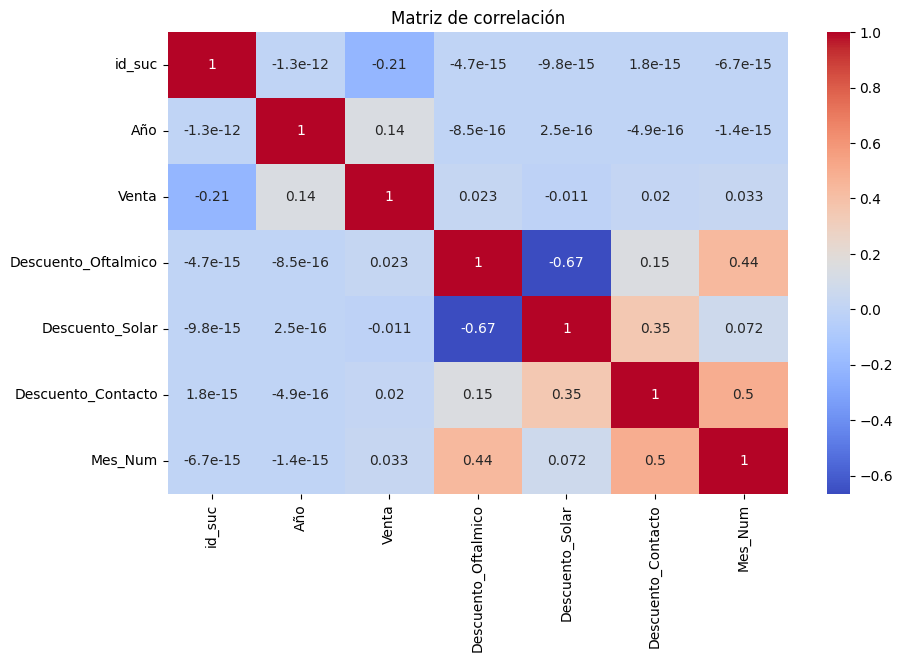

In [33]:
# Heatmap de correlación

plt.figure(figsize=(10,6))

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm'
)

plt.title(
    'Matriz de correlación'
)

plt.show()

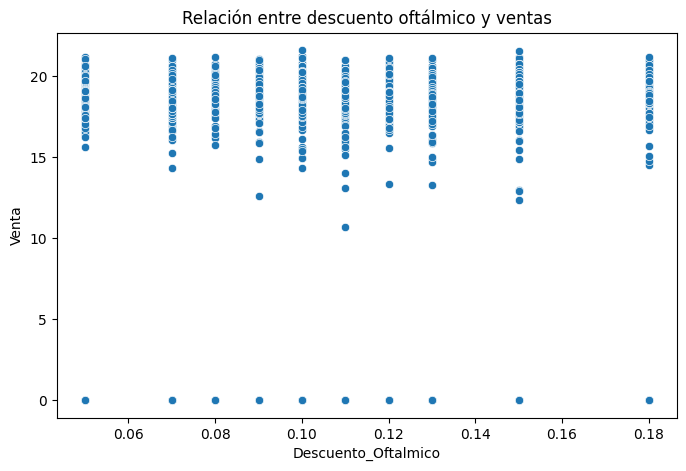

In [34]:
# Relación entre descuento oftálmico y ventas

plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x='Descuento_Oftalmico',
    y='Venta'
)

plt.title(
    'Relación entre descuento oftálmico y ventas'
)

plt.show()

### Relación entre descuentos y ventas

El análisis gráfico permitió explorar la relación entre los descuentos oftálmicos y el comportamiento de las ventas.

La dispersión observada ayuda a identificar posibles patrones de correlación, tendencias comerciales o ausencia de relación lineal fuerte entre ambas variables.

## 11. Insights principales

A partir del análisis exploratorio realizado se identificaron los siguientes hallazgos:

- Las ventas muestran diferencias entre años y meses, sugiriendo posibles patrones de estacionalidad.
- Existen diferencias relevantes entre puntos de venta.
- Algunas sucursales presentan ventas considerablemente altas o bajas, lo que puede indicar posibles outliers.
- Los descuentos incorporados permiten explorar relaciones entre promociones y comportamiento de ventas.
- La variable fecha facilita futuros análisis temporales.

## 12. Guardado del dataset limpio

Finalmente se exporta el dataset limpio y enriquecido para utilizarlo en módulos posteriores del proyecto.

In [35]:
# Exportación del dataset limpio

df.to_csv(
    'mas_vision_dataset_limpio_etapa_2.csv',
    index=False
)

df.to_excel(
    'mas_vision_dataset_limpio_etapa_2.xlsx',
    index=False
)

In [36]:
# Descargar archivos generados

files.download(
    'mas_vision_dataset_limpio_etapa_2.csv'
)

files.download(
    'mas_vision_dataset_limpio_etapa_2.xlsx'
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>